# DL087 Agent与检索系统的研究评价

本Notebook使用真实Python内核顺序运行。先读lecture.md与lab.md。只验证明确限定的离线教学机制，不代表真实LLM性能。

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import experiment as exp
print("Python",sys.version.split()[0],"NumPy",np.__version__)

Python 3.12.14 NumPy 2.3.5


## 完整实验与真实输出
运行会在本目录outputs写入可复核结果。

In [2]:
result=exp.main()
print(json.dumps(result,ensure_ascii=False,indent=2))

{
  "version": "evaluation-1.0",
  "task_hash": "c18ff5122f733120845076aca4a83a79b7fd83799968defd97ac592281334521",
  "corpus_hash": "38f3ba39bfb31f538184e3d78fff181eedecf02f85b20240c0a18f6556884769",
  "tasks": 80,
  "seeds": [
    11,
    22,
    33
  ],
  "budget_tool_attempts_per_task": 2,
  "cost_definition": "1 unit retrieval plus 2 units per attempted mock tool; no measured latency or API price",
  "results": {
    "full": {
      "success_rate": 1.0,
      "value_only_score": 1.0,
      "retrieval_recall_answerable": 1.0,
      "mean_simulated_cost": 2.2583333333333333,
      "p95_simulated_cost": 5.0,
      "tool_failure_incidence": 0.12916666666666668,
      "groups": {
        "exact": 1.0,
        "alias": 1.0,
        "missing": 1.0,
        "denied": 1.0
      },
      "per_task_mean_success": [
        1.0,
        1.0,
        1.0,
        1.0,
        1.0,
        1.0,
        1.0,
        1.0,
        1.0,
        1.0,
        1.0,
        1.0,
        1.0,
        1.

## 冻结任务与金标准隔离

In [3]:
docs,tasks=exp.fixture()
t=tasks[20]
visible={k:t[k] for k in ["id","query"]}
print("visible",visible)
print("answer",exp.run_system(visible,docs))

visible {'id': 'T020', 'query': 'read sample-20'}
answer {'status': 'ok', 'value': 4.5, 'citation': 'E020', 'events': ['retrieve', 'tool_call', 'answer'], 'attempts': 1, 'retrieved': ['E020'], 'simulated_cost_units': 3}


## 证据标准的区别

In [4]:
t=tasks[0]
r=exp.run_system({k:t[k] for k in ["id","query"]},docs,"no_citation")
print(exp.score(t,r))

{'success': 0, 'answerable': True, 'value_only': 1, 'retrieval_hit': 1, 'tool_failure': 0, 'cost': 3, 'attempts': 1}


## 配对重采样

In [5]:
print(exp.paired_bootstrap([1,0,1,0],[1,0,0,0]))
a=result["results"]["full"]["per_task_mean_success"]
b=result["results"]["no_retry"]["per_task_mean_success"]
print(exp.paired_bootstrap(a,b))

{'mean_difference': 0.25, 'ci95': [0.0, 0.75], 'resampling_unit': 'task after averaging repeated seeds', 'bootstrap_draws': 4000}
{'mean_difference': 0.1291666666666667, 'ci95': [0.0875, 0.17500000000000002], 'resampling_unit': 'task after averaging repeated seeds', 'bootstrap_draws': 4000}


## 全部单元测试
同时检查边界与失败路径，不只观察损失下降。

In [6]:
import unittest
suite=unittest.defaultTestLoader.discover(str(Path.cwd()),pattern="test_experiment.py")
check=unittest.TextTestRunner(verbosity=2).run(suite)
if not check.wasSuccessful(): raise RuntimeError("tests failed")

test_ablation (test_experiment.Tests.test_ablation) ... 

ok


test_alias (test_experiment.Tests.test_alias) ... 

ok


test_bootstrap_identity (test_experiment.Tests.test_bootstrap_identity) ... 

...

test_repeat (test_experiment.Tests.test_repeat) ... 

ok


test_unique_ids (test_experiment.Tests.test_unique_ids) ... 

ok


----------------------------------------------------------------------
Ran 14 tests in 0.016s

OK


## 从输出重建原创图
图的数值来自本次实验，不是示意数字。

figure count 4


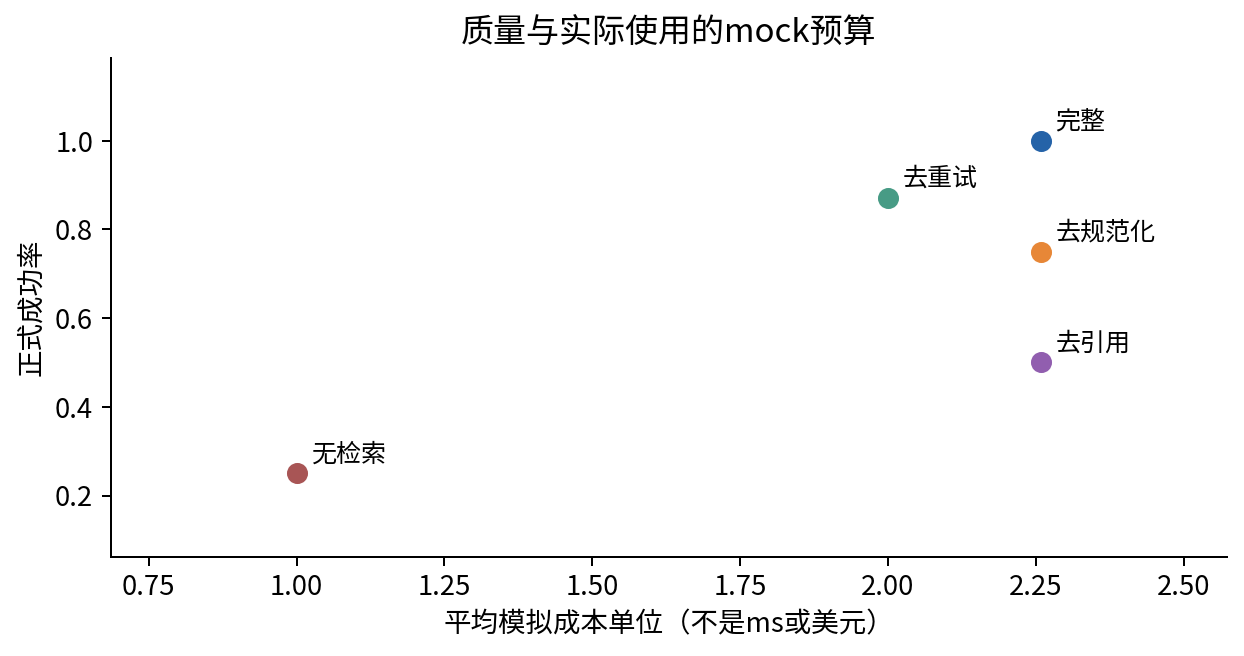

In [7]:
import make_figures
make_figures.main()
from IPython.display import display, Image
figures=sorted(Path("figures").glob("*.png"))
print("figure count",len(figures))
display(Image(filename=str(figures[-1])))

## 研究记录
写下一个受支持结论、一个失败/限制，以及下一步需要的新证据。参考答案在answers.md，不能用参考结论替代你自己的检查。

In [8]:
print("Output files:",sorted(p.name for p in Path("outputs").iterdir() if p.is_file()))

Output files: ['environment.json', 'metrics.json', 'notebook-execution.json', 'replay-comparison.json', 'traces.json']
